In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import multivariate_normal

In [3]:
from tensorflow import cast, float32

## GMM 拆分步骤：
- 0. 初始化，猜测K个类别的均值和方差
- 1. E-step，计算责任矩阵
- 2. M-stop，根据责任矩阵计算更新的均值方差
- 3. 重复1，2，直至收敛。

In [19]:
def multivariate_guassian_pdf(x, mu_k, sigma_k):
    '''
    Input:
    x(ndarray):             single data point (n,)
    mu_k(ndarray):          distribution mean (n,)
    sigma_k(ndarray):       distribution covariance matrix (n,n)

    Output:
    pdf_value(float):       PDF value of that datapoint 
    '''
    n = len(x)
    sigma_k_reg = sigma_k + np.eye(n) * 1e-6 # add a extreme small value to the dial

    if np.linalg.det(sigma_k_reg) <= 0: # If the matrix is not postivite definite the calculation will fill.
        return 1e-10    # When det(sigma_k_reg) <= 0. replace the final result with a small value
    
    sigma_inv = np.linalg.inv(sigma_k_reg)

    # Norm_constant
    norm_const = 1.0 / np.sqrt((2*np.pi) ** n * np.linalg.det(sigma_k_reg))

    # Diff (x-mu)
    diff = (x - mu_k).reshape(n,1)

    # mahalanobis_sq
    ma_sq = diff.T @ sigma_inv @ diff

    # PDF
    pdf = norm_const * np.exp(-0.5 * ma_sq[0][0])

    return pdf

In [20]:
def E_step(X, K, pi, mu, sigma):
    '''
    Input:
    X(ndarray):                 dataset matrix (m, n)
    Distribution(ndarray):      normal distribution parameter matrix (K, 3) [0]: Mixing matrix Pi; [1]: Distribution mean mu; [2]: Covariance matrix

    Output:
    gamma_matrix(ndarray):      probabiltiy list for each dataset (m, K)
    '''
    m, n = X.shape
    likelihoods = np.zeros((m,K))

    for i in range(m):
        for j in range(K):
            likelihoods[i, j] = multivariate_guassian_pdf(X[i], mu[j], sigma[j])
    
    numerator = likelihoods * pi

    gamma_matrix = numerator / np.sum(numerator, axis = 1, keepdims = True).reshape(m,1)

    #total_prob = np.sum()

    return gamma_matrix

In [21]:
def M_step(X, Gamma, reg_covar=1e-6):
    m, n = X.shape
    K = Gamma.shape[1]

    #Nk shape (K,)
    Nk = np.sum(Gamma, axis = 0)
    
    # Update pi (K,)
    pi = Nk/m

    # Update mu (K,n)
    mu = (Gamma.T / Nk.reshape(K,1)) @ X

    # --- 更新 Sigma (协方差) ---
    # 公式: Sigma_k = (sum(gamma_ik * (xi-mu_k)(xi-mu_k)^T)) / Nk
    # 初始化一个空的 3D 数组来存储 K 个协方差矩阵
    sigma = np.zeros((K, n, n))

    for k in range(K):
        diff = X-mu[k]
        sigma_k = ((diff.T * Gamma[:,k]) @ diff) / Nk[k]
        sigma[k] = sigma_k + np.eye(n) * reg_covar

    return pi,mu,sigma 


## 可视化模块

In [9]:
def plot_raw_data(X, m):
    plt.figure(figsize=(10, 6))
    
    # 绘制 Group 1 (前 50 个点)
    plt.scatter(X[:m//2, 0], X[:m//2, 1], c='skyblue', label='Group 1 (Market Regime A)', alpha=0.7, edgecolors='w')
    
    # 绘制 Group 2 (后 50 个点)
    plt.scatter(X[m//2:, 0], X[m//2:, 1], c='salmon', label='Group 2 (Market Regime B)', alpha=0.7, edgecolors='w')
    
    plt.title('S&P 500 Simulated Market Regimes (Raw Data)', fontsize=14)
    plt.xlabel('Feature 1 (e.g., Returns)', fontsize=12)
    plt.ylabel('Feature 2 (e.g., Volatility)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

In [14]:
def plot_gmm_results(X, pi, mu, Sigma):
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5, label='Data Points')
    
    # 创建网格用于绘制等高线
    x, y = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100), np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
    XX, YY = np.meshgrid(x, y)
    pos = np.dstack((XX, YY))
    
    colors = ['blue', 'red', 'green']
    for k in range(len(pi)):
        # 计算该成分的 PDF
        rv = multivariate_normal(mu[k], Sigma[k])
        # 绘制等高线 (Levels 越高代表概率密度越大)
        plt.contour(XX, YY, rv.pdf(pos), levels=5, colors=colors[k], alpha=0.8)
        # 标记均值中心
        plt.plot(mu[k, 0], mu[k, 1], 'X', color=colors[k], markersize=12, label=f'Regime {k} Center')

    plt.title('GMM Learned Regimes and Density Contours', fontsize=14)
    plt.legend()
    plt.show()

## 测试单元

In [4]:
# 生成二维数据
m, n, K = 100, 2, 2
group1 = np.random.randn(m // 2, n) * 0.5 + np.array([0, 1]) 
group2 = np.random.randn(m // 2, n) * 1.0 + np.array([0, 5])
X = np.vstack([group1, group2])


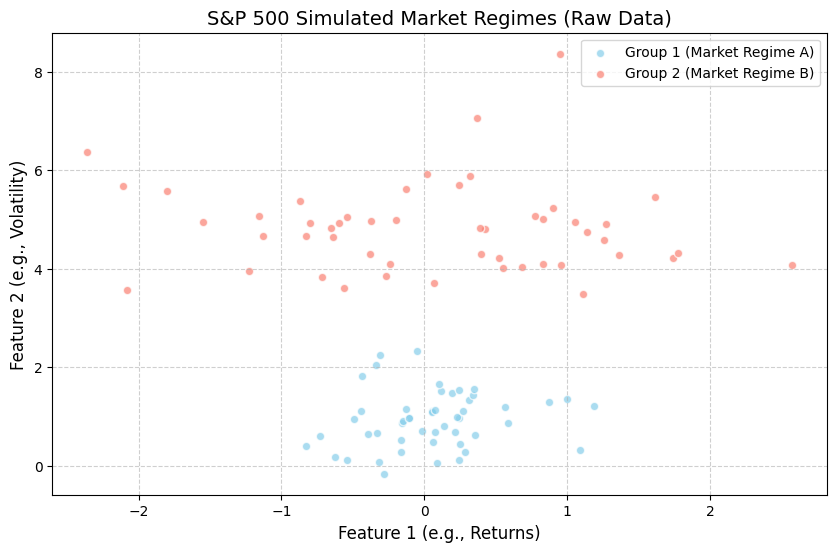

In [11]:
plot_raw_data(X, m)

## 一轮迭代示范

In [22]:
# 1. 我們需要“猜”一組初始參數 (pi, mu, sigma)
# (在真實的EM算法中，這是 Init 步驟)
np.random.seed(42)

# 初始 pi: 假設每個機制佔 50%
pi = np.array([0.5, 0.5])

# 初始 mu: 隨機從數據中選 K 個點 (簡單的初始化)
random_indices = np.random.choice(m, K, replace=False)
mu = X[random_indices]
# mu = np.array([[0, 0], [1, 1]]) # 也可以手動指定

# 初始 sigma: 假設為單位矩陣 (無相關性)
sigma = np.array([np.eye(n)] * K) # 兩個 (2, 2) 的單位矩陣

print("--- 初始參數 ---")
print(f"pi (K,): \n{pi}\n")
print(f"mu (K, n): \n{mu}\n")
print(f"sigma (K, n, n): \n{sigma}\n")

# 2. 運行 E-step！
gamma_matrix = E_step(X, K, pi, mu, sigma)

# 3. 查看結果
print("--- E-Step 輸出 (責任矩陣) ---")
print(f"gamma_matrix 的 shape (m, K): {gamma_matrix.shape}")
print("前 5 行數據的後驗概率:")
print(gamma_matrix[:5])
print("\n後 5 行數據的後驗概率:")
print(gamma_matrix[-5:])
print("\n檢查第一行概率之和 (應為 1.0):", np.sum(gamma_matrix[0]))

# 4. 运行 M-step
new_pi, new_mu, new_sigma = M_step(X, gamma_matrix)
print('---一轮更新参数---')
print(f"pi (K,): \n{new_pi}\n")
print(f"mu (K, n): \n{new_mu}\n")
print(f"sigma (K, n, n): \n{new_sigma}\n")

--- 初始參數 ---
pi (K,): 
[0.5 0.5]

mu (K, n): 
[[-0.5944861  4.920648 ]
 [-0.7969648  4.926413 ]]

sigma (K, n, n): 
[[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]

--- E-Step 輸出 (責任矩陣) ---
gamma_matrix 的 shape (m, K): (100, 2)
前 5 行數據的後驗概率:
[[0.55910002 0.44089998]
 [0.55200733 0.44799267]
 [0.52218797 0.47781203]
 [0.5451229  0.4548771 ]
 [0.54656654 0.45343346]]

後 5 行數據的後驗概率:
[[0.61429408 0.38570592]
 [0.57661778 0.42338222]
 [0.5796449  0.4203551 ]
 [0.62333813 0.37666187]
 [0.42786444 0.57213556]]

檢查第一行概率之和 (應為 1.0): 1.0
---一轮更新参数---
pi (K,): 
[0.54059736 0.45940264]

mu (K, n): 
[[ 0.11819986  2.86063134]
 [-0.01992533  2.89069763]]

sigma (K, n, n): 
[[[ 0.67079958  0.07228831]
  [ 0.07228831  4.31038409]]

 [[ 0.69549185 -0.12618852]
  [-0.12618852  4.36711055]]]



## 多轮迭代测试

In [24]:
#  Test multiround
test_pi = np.array([0.5, 0.5])

# 初始 mu: 隨機從數據中選 K 個點 (簡單的初始化)
test_random_indices = np.random.choice(m, K, replace=False)
test_mu = X[test_random_indices]
# mu = np.array([[0, 0], [1, 1]]) # 也可以手動指定

# 初始 sigma: 假設為單位矩陣 (無相關性)
test_sigma = np.array([np.eye(n)] * K) # 兩個 (2, 2) 的單位矩陣

In [31]:
#这是一个测试模块，每运行一次单元格，就会进行一次GMM迭代，配合下面可以观察GMM收敛。
i = 0
while i <1:
    gamma_matrix = E_step(X, K, test_pi, test_mu, test_sigma)
    test_pi, test_mu, test_sigma = M_step(X, gamma_matrix)
    i += 1
print('--end--')
print('---更新参数---')
print(f"pi (K,): \n{test_pi}\n")
print(f"mu (K, n): \n{test_mu}\n")
print(f"sigma (K, n, n): \n{test_sigma}\n")

--end--
---更新参数---
pi (K,): 
[0.5047239 0.4952761]

mu (K, n): 
[[0.05677787 4.79229968]
 [0.05267292 0.92000338]]

sigma (K, n, n): 
[[[ 1.17765816 -0.08849791]
  [-0.08849791  0.86327363]]

 [[ 0.18673431  0.04193542]
  [ 0.04193542  0.30814931]]]



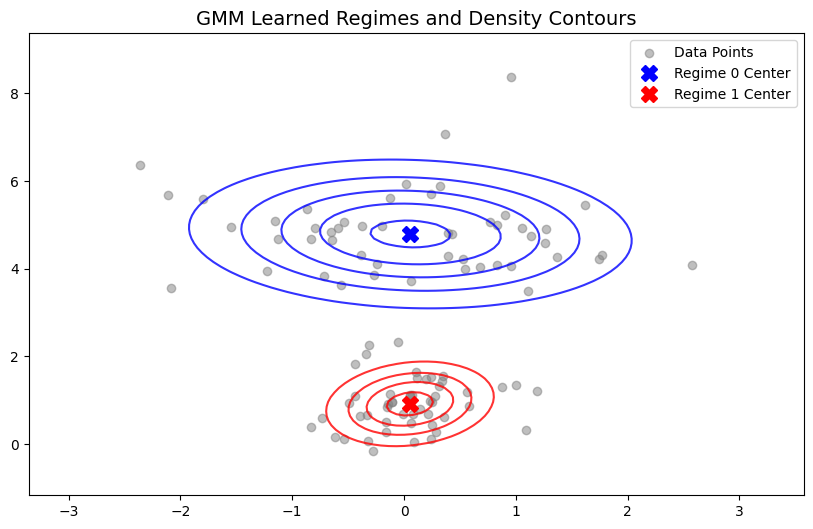

In [32]:
plot_gmm_results(X, test_pi, test_mu,test_sigma)

## TF测试

In [ ]:
X = cast(X, float32)

In [33]:
import GMM

In [ ]:
kmeans_test = GMM.TF_kmeans(K = 2)
mu_init, pi_init, sigma_init = kmeans_test.gmm_init_params(X)

print(mu_init)
print(pi_init)
print(mu_init)

In [ ]:
gmm_test = GMM.TF_GMM(K = 2)
gamma_matrix = gmm_test.fit(X, mu_init, pi_init, sigma_init)
print(gamma_matrix)

In [ ]:
plot_gmm_results(X.numpy(), gmm_test.pi.numpy(), gmm_test.mu.numpy(), gmm_test.sigma.numpy())